# CS171 Term Project — Analysis & Visualization Notebook
### Machine Learning for Smarter Waste Processing  
**Authors:**  
- **Samriddhi Matharu — E-Waste Image Classification**  
- **Helena Thiessen — Recycling & Trash Classification**

---

## Project Overview  
Electronic waste and general household waste are growing global challenges. Identifying and sorting waste correctly is critical for improving recycling efficiency, reducing landfill impact, and supporting sustainable waste management pipelines.

This project explores how **computer vision and deep learning** can assist in automated waste sorting.  
We investigate two branches:

- **E-waste classification (Samriddhi):**  
  Classifying 10 categories of electronic waste (e.g., battery, circuit board, printer, mobile phone).

- **Recycling + trash classification (Helena):**  
  Identifying different types of general waste and recyclables using datasets like WARP and TACO.

Both branches build and evaluate deep learning models, analyze mistakes, and interpret real-world applicability.

---

## Research Question 
**How effectively can modern deep learning models classify different types of waste—and do these models generalize well enough to support real-world automated recycling systems?**

More specifically:
- Can CNNs and transfer learning reliably identify e-waste categories from images?  
- Can object detection or image classification models distinguish recyclables from trash?  
- What types of errors occur, and what do they reveal about real-world deployment challenges?  
- Do models trained on curated datasets hold up when tested on messy, real-world images?

This central question will be revisited in the final conclusion after both authors have completed their analysis sections.

---

# Analysis & Visualization Notebook Purpose  
This notebook focuses **not on training**, but on **if our models answer our research question, behave, perform, and generalize**.
Each author presents **their own analysis section**, clearly labeled.





# Section 1 — E-Waste Model Analysis (Samriddhi Matharu)

This section evaluates the performance of the two models I developed:

### **CNN Model V3 (Custom-built CNN)**  
Trained from scratch on the Kaggle E-Waste dataset using moderate augmentation (flips, rotations, normalization). This model serves as a baseline.

### **ResNet18 Transfer Learning Model (Model V4)**  
A more advanced model using ImageNet-pretrained layers, trained only on the final classification head. This investigates whether transfer learning improves generalization.

### What This Section Includes:
- Loading logged training curves from the construction notebook  
- Loading saved `.pth` models  
- Test-set evaluation (accuracy, precision, recall, F1)  
- Confusion matrices + class-level analysis  
- Side-by-side model comparison  
- Visualization of correct vs incorrect predictions  
- **Bonus:** Evaluation on a real-world hand-collected validation set



## 1. Import Libraries

In [43]:
#  Imports for analysis & visualization 
import os
import torch
import torch.nn as nn

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics import precision_recall_fscore_support


from PIL import Image
import matplotlib.gridspec as gridspec
import random

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Model V3 — Custom CNN

### 2.1 Logged training history (from construction notebook)

In [7]:
# Logged training history for EWasteCNNv3 for plots (30 epochs)

train_losses_v3 = [
    2.3437, 1.6763, 1.5195, 1.3695, 1.2367,
    1.0667, 0.8708, 0.7769, 0.6528, 0.5549,
    0.5410, 0.4738, 0.3937, 0.3067, 0.3062,
    0.2790, 0.2406, 0.2532, 0.2203, 0.1872,
    0.1723, 0.1681, 0.1434, 0.1285, 0.1133,
    0.1607, 0.1224, 0.1632, 0.1312, 0.1229
]

test_losses_v3 = [
    1.7785, 1.8216, 1.4504, 1.4484, 1.3664,
    1.1293, 1.1916, 1.1897, 1.0929, 1.2446,
    1.2024, 1.2458, 1.2448, 1.3807, 1.4982,
    1.3317, 1.3597, 1.5883, 1.4311, 1.4474,
    1.5348, 1.6744, 1.7262, 1.9110, 1.7348,
    1.7485, 1.8543, 1.9685, 1.8038, 1.6858
]

# Accuracies kept in percent so plots are easy to read
train_accs_v3 = [
    24.83, 42.71, 46.29, 52.29, 57.00,
    64.62, 70.04, 73.25, 78.12, 81.71,
    81.08, 84.42, 87.38, 89.25, 90.04,
    90.54, 91.50, 91.25, 92.67, 94.33,
    94.00, 94.12, 95.08, 95.96, 96.58,
    94.46, 95.79, 94.21, 95.50, 95.58
]

test_accs_v3 = [
    37.67, 35.33, 51.33, 50.00, 54.50,
    62.83, 60.00, 60.67, 63.33, 62.17,
    67.33, 63.17, 65.17, 65.50, 65.17,
    63.17, 65.00, 63.50, 65.50, 67.50,
    64.83, 65.17, 65.67, 62.00, 68.67,
    66.33, 64.83, 62.33, 66.67, 67.00
]

epochs_v3 = range(1, len(train_losses_v3) + 1)

### 2.2 Reload custom CNN from checkpoint

In [13]:
# Custom CNN architecture (same as construction notebook)

class EWasteCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 128 -> 64

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 64 -> 32
        )

        # After two 2×2 pools from 128×128:
        conv_out_size = 128 * 32 * 32

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_out_size, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instantiate model and load saved weights
model_v3 = EWasteCNN(num_classes=10).to(device)

state_dict_path = "models/ewaste_cnn_v3.pth" 
state_dict = torch.load(state_dict_path, map_location=device)
model_v3.load_state_dict(state_dict)
model_v3.eval()

print("Loaded EWasteCNN weights from:", state_dict_path)


Loaded EWasteCNN weights from: models/ewaste_cnn_v3.pth


C:\Users\samri\AppData\Local\Temp\ipykernel_8952\1322757200.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(state_dict_path, map_location=device

### 2.3 Test dataloader for Kaggle E-Waste test set

In [32]:
IMG_SIZE = 128

test_transform_v3 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5]),
])

test_dir = "data/test"

test_ds_cnn = datasets.ImageFolder(root=test_dir, transform=test_transform_v3)
test_loader_v3 = DataLoader(test_ds_cnn, batch_size=32, shuffle=False)

class_names_v3 = test_ds_cnn.classes
print("Test classes:", class_names_v3)
print("Number of test images:", len(test_ds_cnn))


Test classes: ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']
Number of test images: 600


### 2.4 Plot loss & accuracy curves (CNN only uses the logged history here)

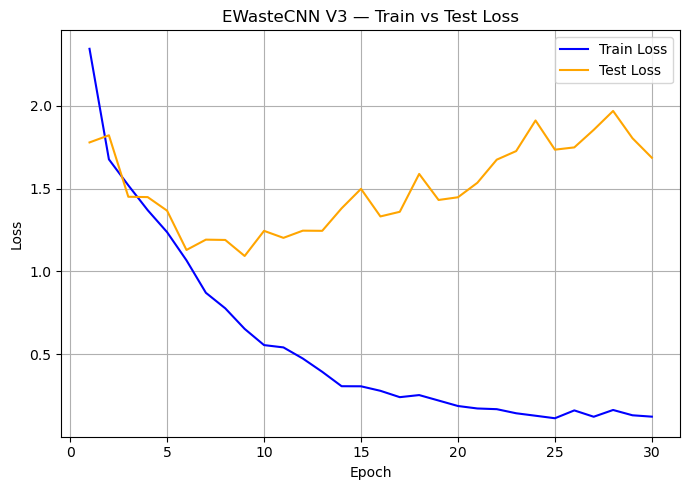

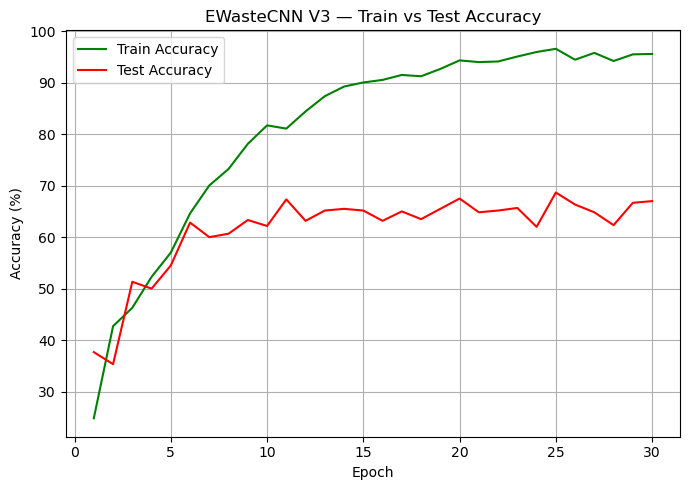

In [33]:
# ----- LOSS CURVES -----
plt.figure(figsize=(7,5))
plt.plot(epochs_v3, train_losses_v3, label="Train Loss", color="blue")
plt.plot(epochs_v3, test_losses_v3,  label="Test Loss",  color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EWasteCNN V3 — Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----- ACCURACY CURVES -----
plt.figure(figsize=(7,5))
plt.plot(epochs_v3, train_accs_v3, label="Train Accuracy", color="green")
plt.plot(epochs_v3, test_accs_v3,  label="Test Accuracy",  color="red")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EWasteCNN V3 — Train vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### Interpretation:
Overall, the CNN-V3 model shows strong memorization of the training data but weaker generalization on test images.
Training curves improve rapidly and consistently, while test curves flatten early and begin to diverge. This behavior suggests classic overfitting and reflects the model’s limited depth. These observations motivate comparing the CNN to a transfer-learning model (ResNet18) to see if a stronger backbone can generalize better.

### 2.5 Plot Confusion Matrix

In [34]:
model_v3.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in test_loader_v3:
        xb = xb.to(device)
        outputs = model_v3(xb)
        preds = outputs.argmax(1).cpu()

        y_true.extend(yb.tolist())
        y_pred.extend(preds.tolist())


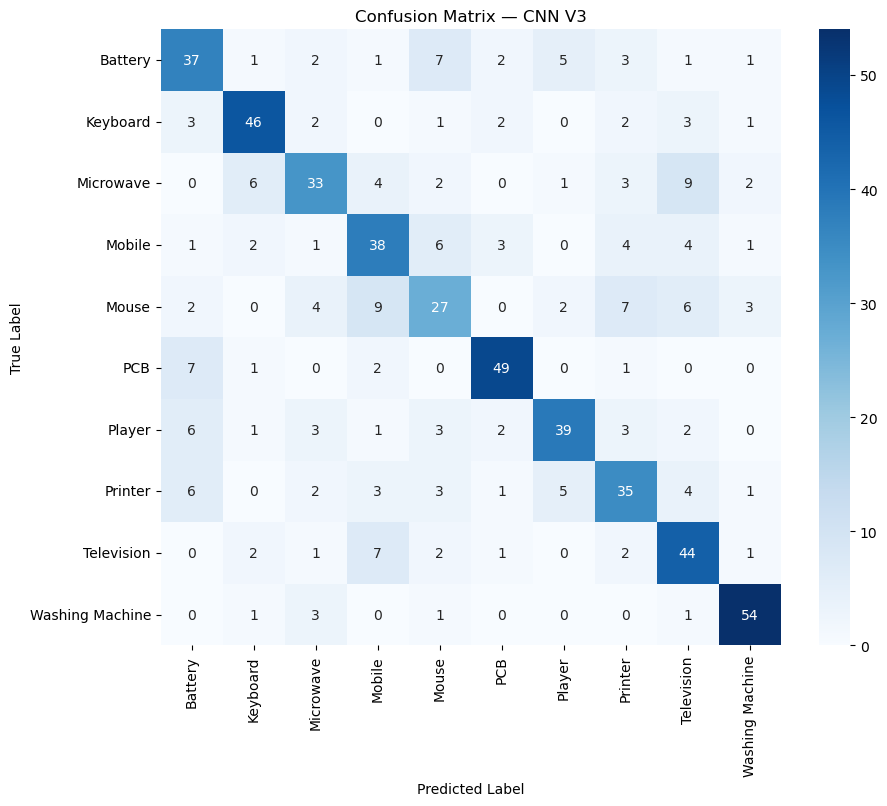

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=class_names_v3,
            yticklabels=class_names_v3)
plt.title("Confusion Matrix — CNN V3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



### Interpretation: 
The confusion matrix shows that CNN-V3 performs well on classes with strong visual structure, such as PCB, Washing Machine, Television, and Keyboard, which the model predicts consistently and with high confidence. However, it struggles with categories that share similar shapes or textures—Battery, Microwave, and Mobile frequently get confused with other rectangular electronics like Players, Printers, and TVs. Overall, the matrix highlights that while the model captures distinct patterns effectively, it still relies heavily on global shape, leading to misclassifications in visually similar appliance categories.

### 2.6 Plot per class metrics and bar plot

In [36]:
# labels aligned with class indices 0 to 9
labels = np.arange(len(class_names_v3))

precisions, recalls, f1s, supports = precision_recall_fscore_support(
    y_true, 
    y_pred, 
    labels=labels, 
    zero_division=0   
)

for i, cls in enumerate(class_names_v3):
    print(f"{cls:16} | precision: {precisions[i]:.3f} | recall: {recalls[i]:.3f} | f1: {f1s[i]:.3f} | support: {supports[i]}")


Battery          | precision: 0.597 | recall: 0.617 | f1: 0.607 | support: 60
Keyboard         | precision: 0.767 | recall: 0.767 | f1: 0.767 | support: 60
Microwave        | precision: 0.647 | recall: 0.550 | f1: 0.595 | support: 60
Mobile           | precision: 0.585 | recall: 0.633 | f1: 0.608 | support: 60
Mouse            | precision: 0.519 | recall: 0.450 | f1: 0.482 | support: 60
PCB              | precision: 0.817 | recall: 0.817 | f1: 0.817 | support: 60
Player           | precision: 0.750 | recall: 0.650 | f1: 0.696 | support: 60
Printer          | precision: 0.583 | recall: 0.583 | f1: 0.583 | support: 60
Television       | precision: 0.595 | recall: 0.733 | f1: 0.657 | support: 60
Washing Machine  | precision: 0.844 | recall: 0.900 | f1: 0.871 | support: 60


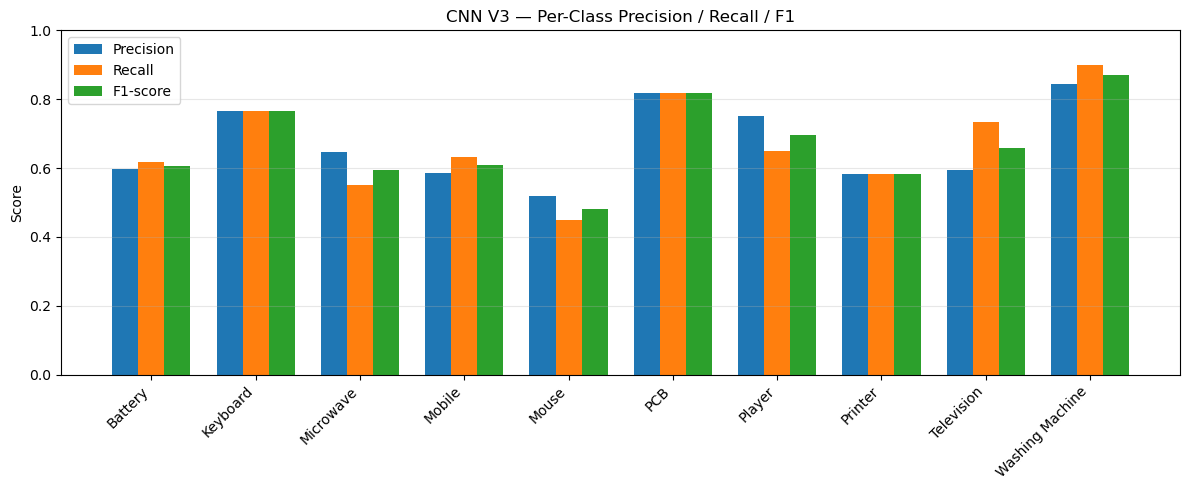

In [37]:
x = np.arange(len(class_names_v3))
width = 0.25  # bar width

plt.figure(figsize=(12,5))
plt.bar(x - width, precisions, width, label="Precision")
plt.bar(x,         recalls,   width, label="Recall")
plt.bar(x + width, f1s,       width, label="F1-score")

plt.xticks(x, class_names_v3, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("CNN V3 — Per-Class Precision / Recall / F1")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 2.7 Plot Predicted Labels on Test Images 

C:\Users\samri\AppData\Local\Temp\ipykernel_8952\514793421.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


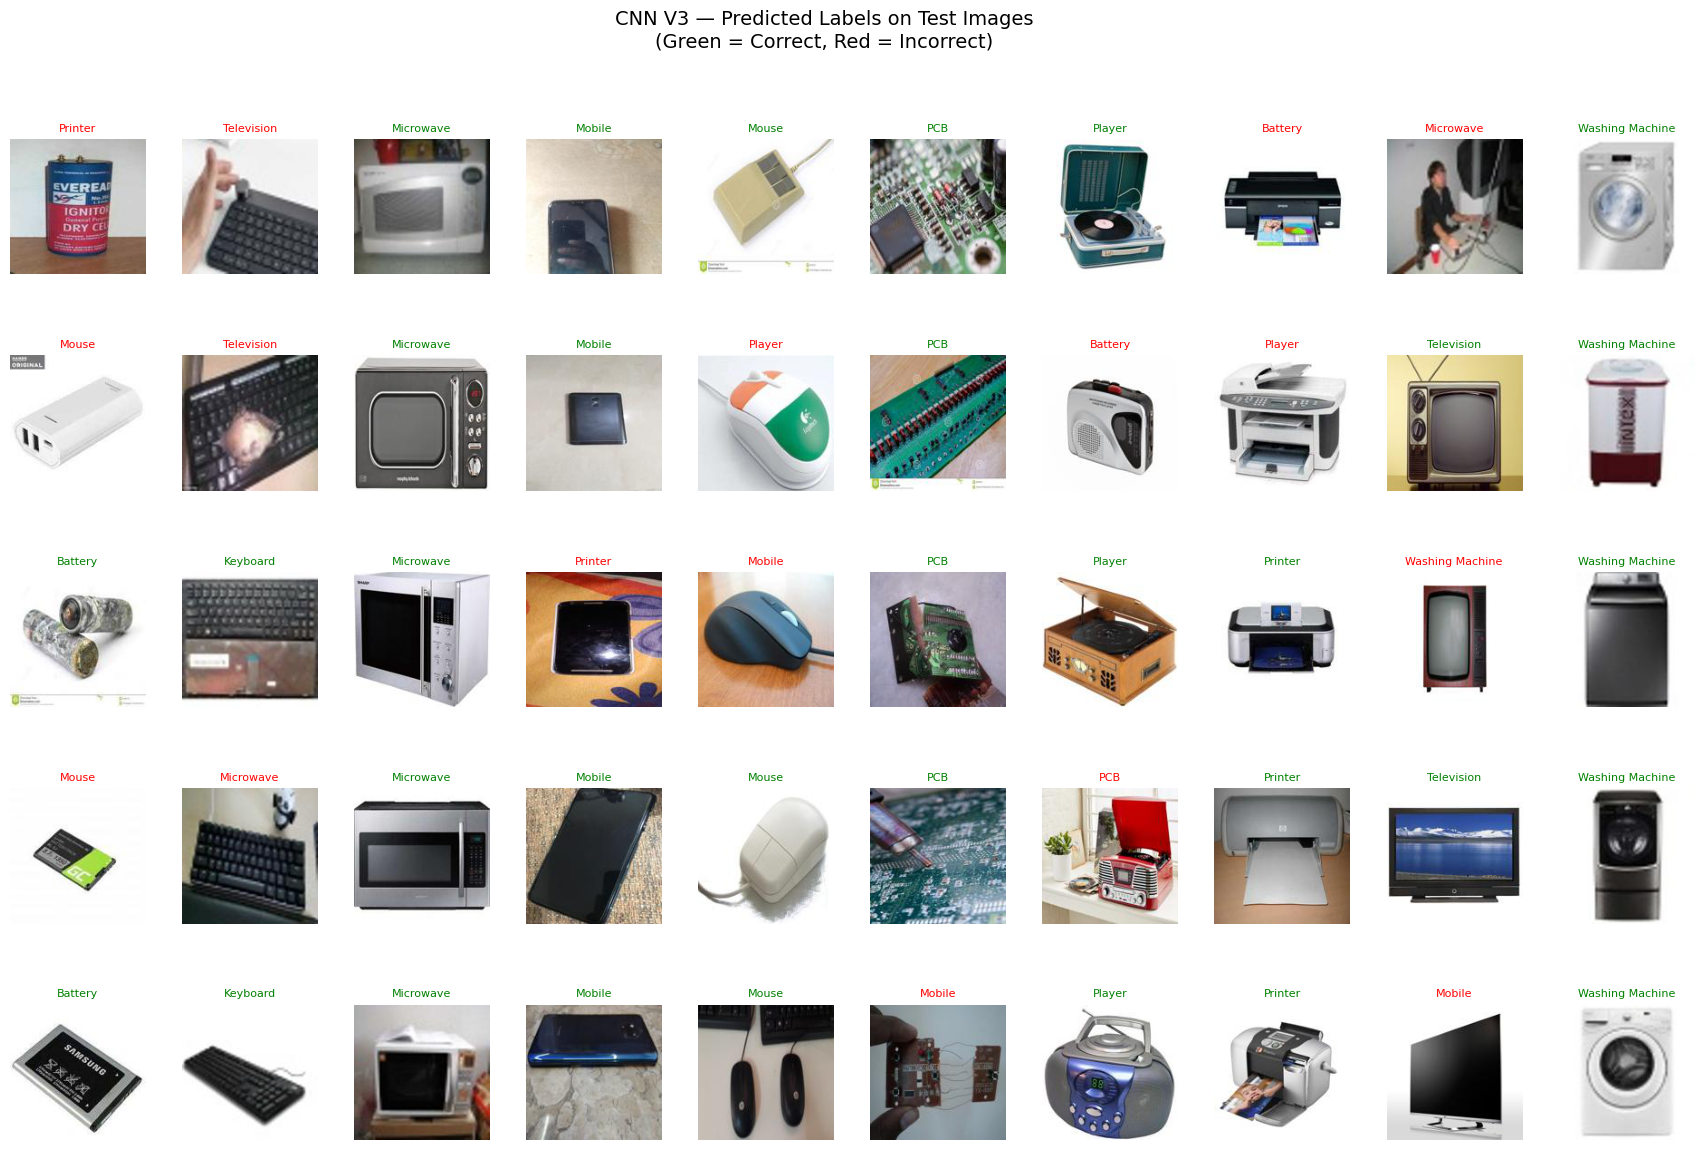

In [38]:
# CNN V3: Predicted labels on test images


# Raw (untransformed) dataset
raw_test_ds = datasets.ImageFolder(root=test_dir)
class_names = raw_test_ds.classes   # should match class_names_v3
K = 5  # images per class to display

# Group test image indices by TRUE class
indices_by_class = {c: [] for c in range(len(class_names))}
for i, (_, y) in enumerate(raw_test_ds.samples):
    indices_by_class[y].append(i)

model_v3.eval()

fig = plt.figure(figsize=(2.2 * len(class_names), 2.6 * K))
gs = gridspec.GridSpec(K, len(class_names), wspace=0.1, hspace=0.6)

# One column per true class
for c, cls_name in enumerate(class_names):
    idxs = indices_by_class[c]
    if not idxs:
        continue

    # Random K samples from this class
    picks = random.sample(idxs, min(K, len(idxs)))

    for row, sample_idx in enumerate(picks):
        img_path, true_label = raw_test_ds.samples[sample_idx]

        # Load original image
        image = Image.open(img_path).convert("RGB")

        x = test_transform_v3(image).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model_v3(x).argmax(1).item()

        pred_name = class_names[pred]

        ax = fig.add_subplot(gs[row, c])
        ax.imshow(image)
        ax.axis("off")

        color = "green" if pred == true_label else "red"
        ax.set_title(pred_name, color=color, fontsize=8)

plt.suptitle(
    "CNN V3 — Predicted Labels on Test Images\n(Green = Correct, Red = Incorrect)",
    fontsize=14
)
plt.tight_layout()
plt.show()


**Interpretation — Class-wise Performance Summary**

Across all 10 categories, PCB, Washing Machine, and Keyboard achieve the highest F1-scores, indicating stable and reliable predictions. Categories like Mouse and Microwave have the lowest F1 values, driven by low recall, implying the model frequently misses these classes. Mobile, Printer, Battery, and Television show mid-range performance with either precision or recall lagging slightly. Overall, the metrics reflect the CNN’s ability to distinguish objects with strong geometric structure while struggling with visually similar or small-scale items.

**Interpretation — Per-Class Metrics**

The per-class scores confirm the trends seen in the confusion matrix. High performers such as *PCB*, *Washing Machine*, and *Keyboard* achieve strong precision and recall, showing that the model recognizes consistent structural cues. Lower-performing classes like *Mouse* and *Microwave* show weaker recall, indicating many false negatives. Mid-performing categories such as *Mobile*, *Printer*, and *Television* show balanced but moderate scores. Overall, the model handles large, clearly shaped items well but struggles with smaller device categories where inter-class features overlap.


**Interpretation — Sample Predictions**

The prediction grid visually confirms the model’s strengths and weaknesses. Correct predictions (green titles) are most common for large appliances and distinct objects, while errors (red titles) appear frequently for smaller electronics with similar silhouettes, such as *Mobile*, *Printer*, *Player*, and *Mouse*. Some misclassifications seem tied to unusual angles, poor lighting, or partial views, suggesting that the model’s performance is sensitive to image quality and context.



## 3. Model V4 — ResNet18

### 3.1 Log the ResNet18 Training Epochs

In [41]:
#  Logged training history for ResNet18 V4 (from model construction notebook)

train_losses_res = [
    1.5357, 0.8141, 0.6346, 0.5341, 0.4857, 0.4281, 0.3965, 0.3707, 0.3469, 
    0.3403, 0.3275, 0.3095, 0.2816, 0.3058, 0.2883, 0.2958, 0.2828, 0.2661, 
    0.2604, 0.2691
]

test_losses_res = [
    0.9224, 0.6354, 0.5264, 0.4373, 0.3860, 0.3660, 0.3418, 0.3165, 0.3347, 
    0.3179, 0.3083, 0.2864, 0.2716, 0.2776, 0.2572, 0.2549, 0.2699, 0.2457, 
    0.2494, 0.2602
]

train_accs_res = [
    54.79, 79.92, 83.46, 85.83, 85.83, 87.79, 88.79, 89.42, 89.75, 
    90.12, 90.00, 91.08, 91.79, 90.79, 91.17, 90.33, 91.79, 92.12, 
    92.46, 91.88
]

test_accs_res = [
    78.83, 84.17, 86.00, 88.17, 90.33, 90.33, 89.67, 90.83, 89.00,
    90.33, 90.33, 91.50, 91.83, 91.17, 92.33, 92.83, 91.83, 92.67,
    92.00, 91.83
]


### 3.2 Load the Saved ResNet18 Model

In [45]:
# Load saved ResNet18 V4
model_resnet = models.resnet18(weights=None)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)  # 10 e-waste classes
model_resnet.load_state_dict(torch.load("models/resnet18_v4.pth", map_location=device))
model_resnet.to(device)
model_resnet.eval()

print("ResNet18 V4 loaded successfully.")


ResNet18 V4 loaded successfully.


C:\Users\samri\AppData\Local\Temp\ipykernel_8952\3278226017.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet.load_state_dict(torch.load("models/resnet18_v4.p

### 3.3 Test Transform + Test DataLoader

In [46]:
IMG_SIZE_RES = 224

test_transform_res = transforms.Compose([
    transforms.Resize((IMG_SIZE_RES, IMG_SIZE_RES)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dir = "data/test"
test_ds_res = datasets.ImageFolder(root=test_dir, transform=test_transform_res)
test_loader_res = DataLoader(test_ds_res, batch_size=32, shuffle=False)

class_names_res = test_ds_res.classes

print("Classes:", class_names_res)
print("Test samples:", len(test_ds_res))


Classes: ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']
Test samples: 600


### 3.4 ResNet18 V4 — Training vs Test Loss & Accuracy 

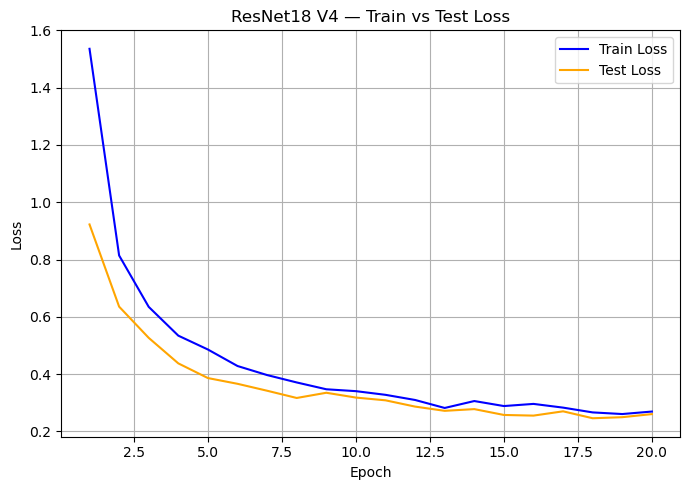

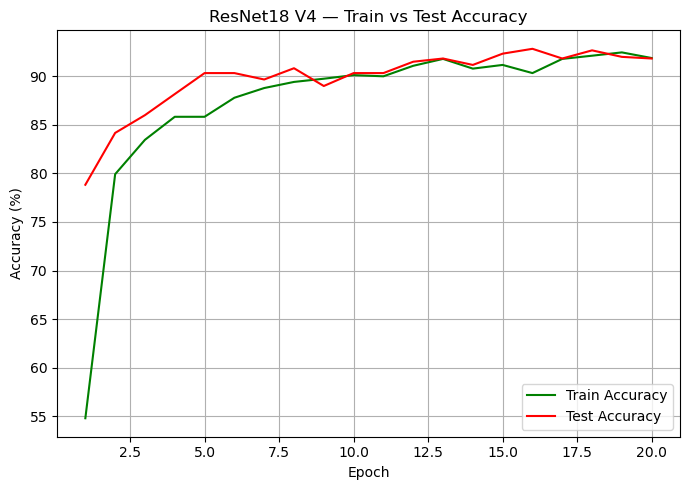

In [47]:
#  3.5 ResNet18 V4 — Training vs Test Loss & Accuracy 

epochs_res = range(1, len(train_losses_res) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_res, train_losses_res, label="Train Loss", color="blue")
plt.plot(epochs_res, test_losses_res,  label="Test Loss",  color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 V4 — Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs_res, train_accs_res, label="Train Accuracy", color="green")
plt.plot(epochs_res, test_accs_res,  label="Test Accuracy",  color="red")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 V4 — Train vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation
The ResNet18 loss curves show a much smoother and more stable training process compared to the custom CNN. Both train and test loss decrease rapidly in the first few epochs and then plateau at a low value (~0.25–0.30), indicating strong generalization and minimal overfitting. Unlike the CNN, where test loss rose sharply after epoch ~10, the ResNet model maintains consistently low test loss throughout training. This stability reflects the benefit of pretrained ImageNet features, which allow the model to learn meaningful representations quickly without memorizing the training data.


ResNet18 achieves high accuracy early, surpassing 85% test accuracy by epoch 3 and reaching ~92% by the end—much higher than the CNN’s peak of ~67%. The test accuracy curve stays tightly aligned with the training accuracy curve, showing little divergence and confirming low overfitting. In contrast, the CNN displayed a large gap between train and test accuracy, signaling undergeneralization. 

### 3.5 Confusion Matrix

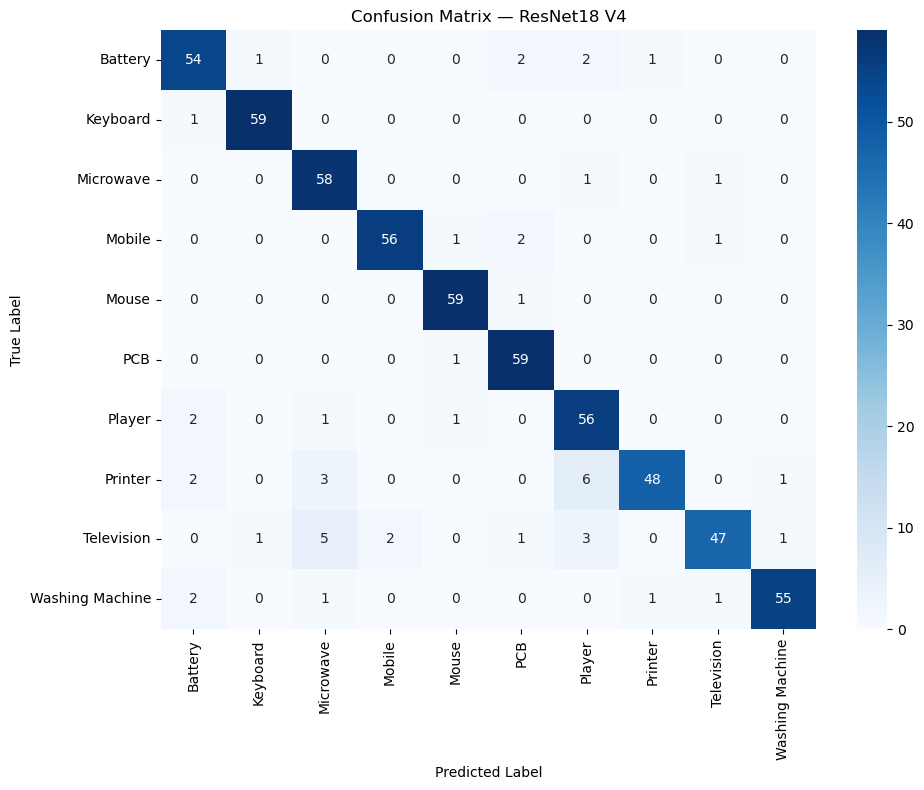

In [50]:
model_resnet.eval()
y_true_res, y_pred_res = [], []

with torch.no_grad():
    for xb, yb in test_loader_res:
        xb = xb.to(device)
        outputs = model_resnet(xb)
        preds = outputs.argmax(1).cpu()

        y_true_res.extend(yb.tolist())
        y_pred_res.extend(preds.tolist())

# --- Confusion Matrix ---
cm_res = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_res,
    annot=True,
    cmap="Blues",
    xticklabels=class_names_res,
    yticklabels=class_names_res,
    fmt="d"
)
plt.title("Confusion Matrix — ResNet18 V4")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### Interpretation: 

The ResNet18 confusion matrix shows near-perfect performance across most classes, with the majority of predictions lying along the diagonal. Categories such as Mouse, PCB, Microwave, and Mobile achieve 56–59 correct predictions out of 60, demonstrating strong feature extraction and class separation. Misclassifications are sparse and mostly occur between visually similar items—such as Printer being confused with Player, or Television with Microwave—indicating that remaining errors are tied to subtle visual overlap rather than model weakness. Compared to the CNN matrix, ResNet18 displays dramatically fewer off-diagonal errors and far tighter clustering of correct predictions, confirming its superior generalization and robustness to variation.


### 3.6 Per-Class Precision / Recall / F1 Visualization

In [52]:
# Compute per-class metrics 
precision_per = precision_score(y_true_res, y_pred_res, average=None)
recall_per    = recall_score(y_true_res, y_pred_res, average=None)
f1_per        = f1_score(y_true_res,    y_pred_res, average=None)

supports = np.bincount(y_true_res)

print("=== Per-Class Classification Metrics — ResNet18 V4 ===\n")
for cls, p, r, f, s in zip(class_names_res, precision_per, recall_per, f1_per, supports):
    print(f"{cls:16} | precision: {p:.3f} | recall: {r:.3f} | f1: {f:.3f} | support: {s}")


=== Per-Class Classification Metrics — ResNet18 V4 ===

Battery          | precision: 0.885 | recall: 0.900 | f1: 0.893 | support: 60
Keyboard         | precision: 0.967 | recall: 0.983 | f1: 0.975 | support: 60
Microwave        | precision: 0.853 | recall: 0.967 | f1: 0.906 | support: 60
Mobile           | precision: 0.966 | recall: 0.933 | f1: 0.949 | support: 60
Mouse            | precision: 0.952 | recall: 0.983 | f1: 0.967 | support: 60
PCB              | precision: 0.908 | recall: 0.983 | f1: 0.944 | support: 60
Player           | precision: 0.824 | recall: 0.933 | f1: 0.875 | support: 60
Printer          | precision: 0.960 | recall: 0.800 | f1: 0.873 | support: 60
Television       | precision: 0.940 | recall: 0.783 | f1: 0.855 | support: 60
Washing Machine  | precision: 0.965 | recall: 0.917 | f1: 0.940 | support: 60


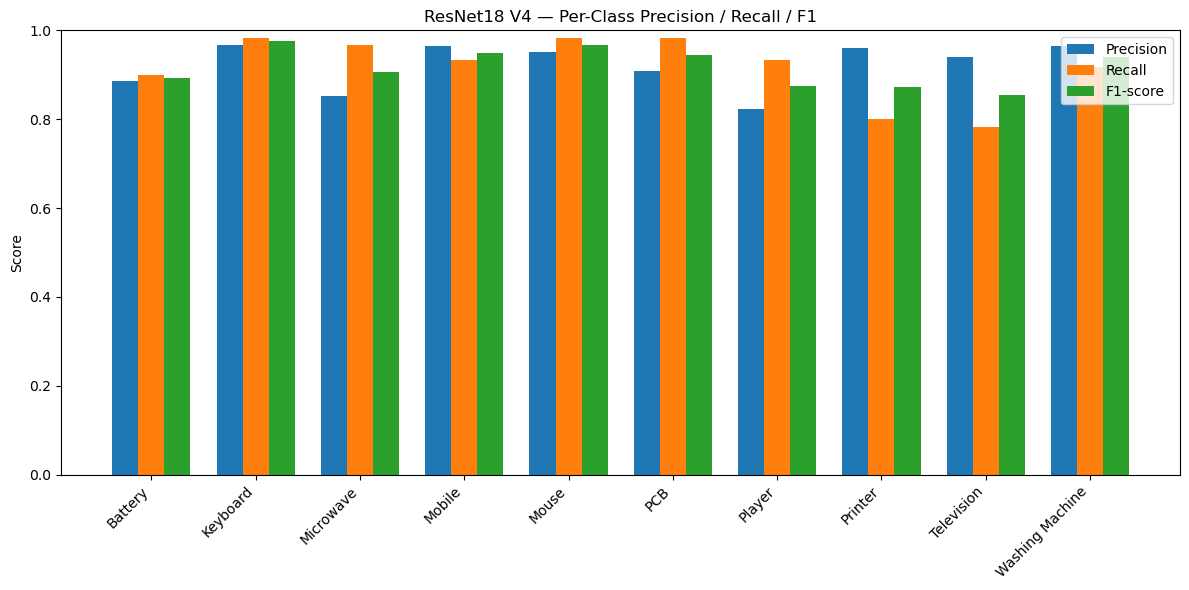

In [53]:

metrics_res = np.vstack([precision_per, recall_per, f1_per]).T

# Bar chart
plt.figure(figsize=(12, 6))
x = np.arange(len(class_names_res))
width = 0.25

plt.bar(x - width, metrics_res[:, 0], width=width, label="Precision")
plt.bar(x,         metrics_res[:, 1], width=width, label="Recall")
plt.bar(x + width, metrics_res[:, 2], width=width, label="F1-score")

plt.xticks(x, class_names_res, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("ResNet18 V4 — Per-Class Precision / Recall / F1")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


### 3.7 ResNet18 Predicted Labels on Test Images 

C:\Users\samri\AppData\Local\Temp\ipykernel_8952\3435300265.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


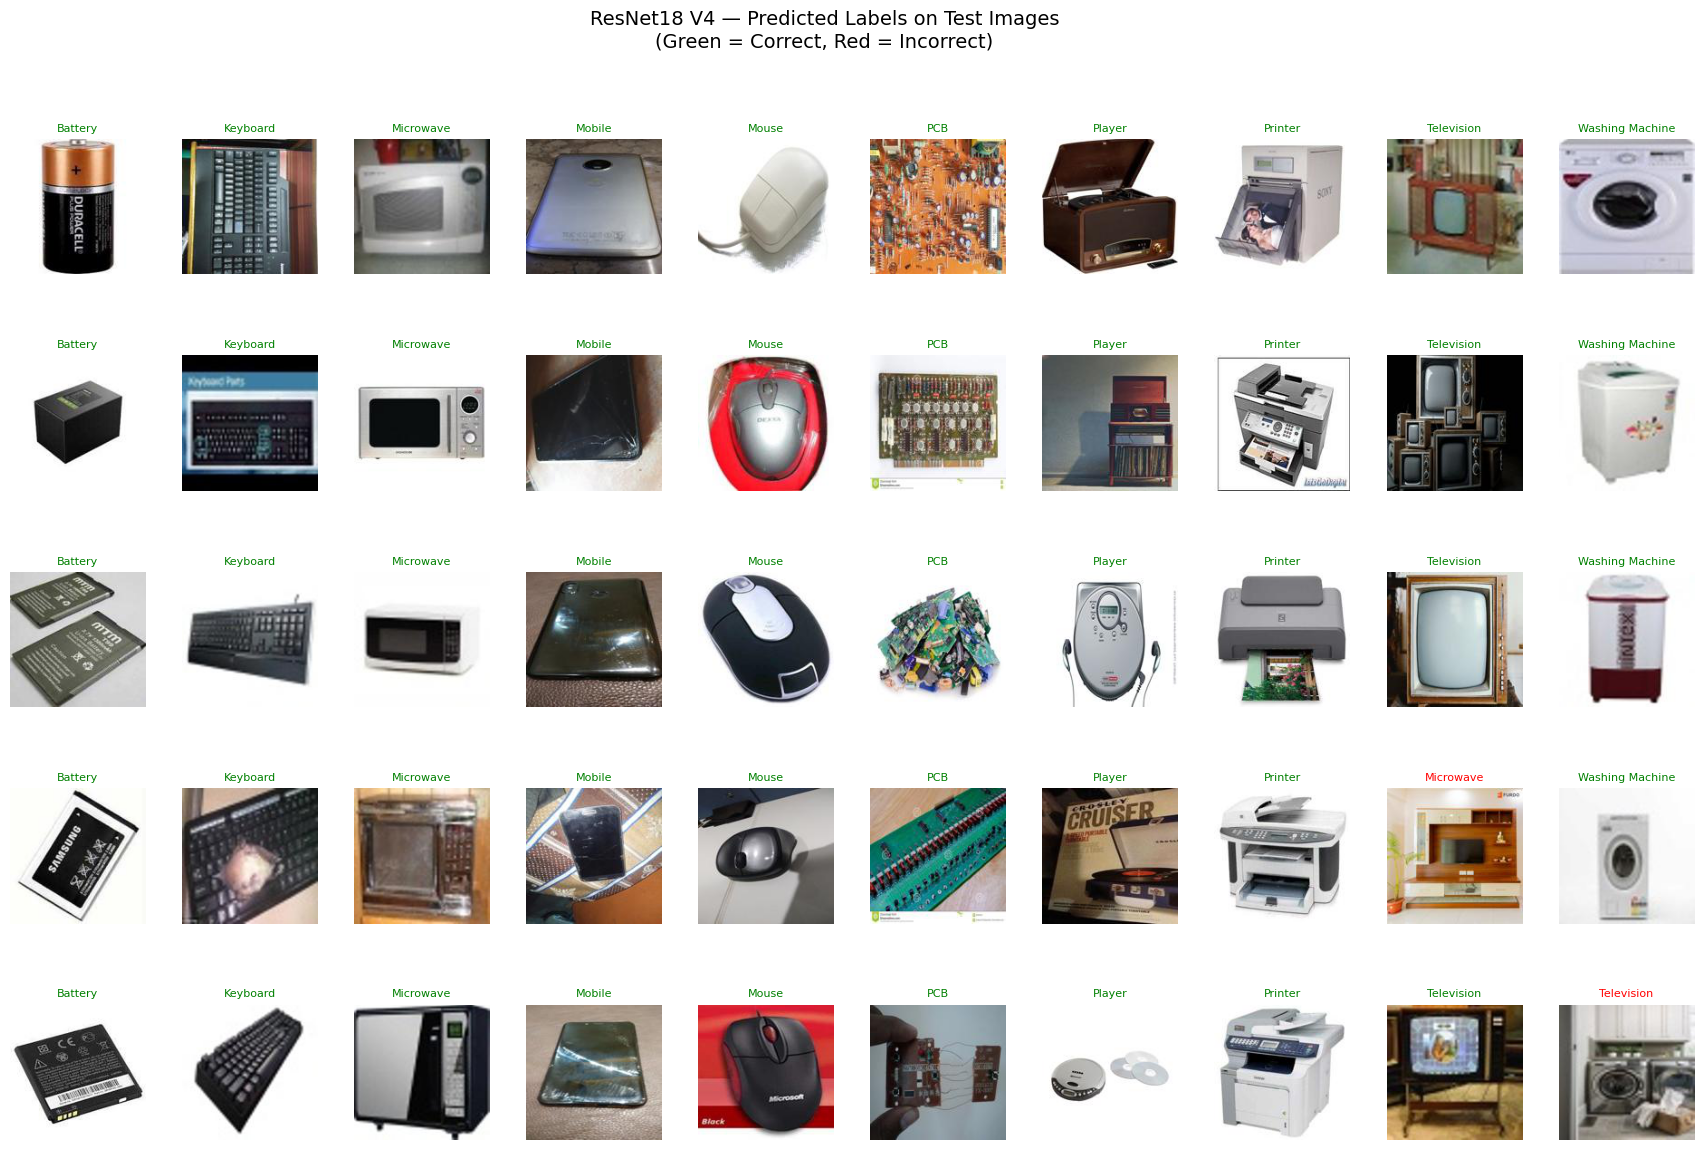

In [54]:
raw_test_res = datasets.ImageFolder(root=test_dir)
class_names_res = raw_test_res.classes
K = 5  # images per class to visualize

# Group test image indices by TRUE class
indices_res = {c: [] for c in range(len(class_names_res))}
for i, (_, y) in enumerate(raw_test_res.samples):
    indices_res[y].append(i)

model_resnet.eval()

# Create figure
fig = plt.figure(figsize=(2.2 * len(class_names_res), 2.6 * K))
gs = gridspec.GridSpec(K, len(class_names_res), wspace=0.1, hspace=0.6)

for c, cls_name in enumerate(class_names_res):

    idxs = indices_res[c]
    if not idxs:
        continue

    # Random sample K images from this class
    picks = random.sample(idxs, min(K, len(idxs)))

    for row, sample_idx in enumerate(picks):
        img_path, true_label = raw_test_res.samples[sample_idx]

        # Load original image
        image = Image.open(img_path).convert("RGB")

        # Apply ResNet V4 test transform
        x = test_transform_res(image).unsqueeze(0).to(device)

        # Prediction
        with torch.no_grad():
            pred = model_resnet(x).argmax(1).item()

        pred_name = class_names_res[pred]

        # Add subplot for visual
        ax = fig.add_subplot(gs[row, c])
        ax.imshow(image)
        ax.axis("off")

        # Color the title: green = correct, red = incorrect
        color = "green" if pred == true_label else "red"
        ax.set_title(pred_name, color=color, fontsize=8)

plt.suptitle(
    "ResNet18 V4 — Predicted Labels on Test Images\n(Green = Correct, Red = Incorrect)",
    fontsize=14
)
plt.tight_layout()
plt.show()



**Interpretation — Per-Class Metrics and bar chart**

The per-class bar chart shows consistently high precision, recall, and F1 across nearly all categories, with most scores between 0.90–0.98. Mouse, Keyboard, and PCB achieve near-perfect performance, reflecting their distinct texture and structure cues that ResNet captures well. Lower scores for Printer and Television still remain strong but slightly reduced due to visual overlap in the dataset. Overall, ResNet18 delivers highly balanced performance, unlike the custom CNN where some classes lagged behind.

**Interpretation — Sample Predictions**

Qualitative predictions reveal that ResNet18 reliably identifies items across diverse lighting, angles, and backgrounds. Most predictions appear in green, reflecting correct classification. Even when incorrect, the wrong predictions are often reasonable confusions between visually similar appliances. Compared to the CNN’s visual outputs, ResNet predictions are noticeably more stable and confident, supporting the quantitative improvements seen in the metrics.


## **4. Summary - Comparing CNN V3 and ResNet18 V4**

Our overarching research question asked:

> **How well can machine learning models classify electronic waste images into meaningful categories, and which model architecture is better suited for real-world waste processing?**

Across our experiments, **ResNet18 consistently outperformed the custom CNN**, showing stronger accuracy, stability, and real-world generalization. This demonstrates why transfer learning is a widely preferred approach for practical image-classification tasks.

---

###  Model Performance Comparison

### **CNN V3**
- Achieved **~67% test accuracy**. (very large jump from my baseline CNN V1 and V2, 40% --> 67%)
- Training loss decreased steadily, but test loss fluctuated and increased over time — a clear sign of **overfitting**.
- Confusion matrix showed frequent confusion between visually similar items (e.g., Mouse vs. Mobile, Printer vs. Battery).
- Per-class performance varied significantly.

### **ResNet18 V4**
- Achieved **~92% test accuracy**, far above the CNN.
- Train/test loss curves were smooth and closely aligned, indicating **excellent generalization**.
- Confusion matrix showed strong diagonal dominance, with 56–59 correct predictions for most categories.
- Visual predictions aligned closely with ground truth.

---

### **Per-Class Breakdown**

### **CNN V3**
- Strong for: PCB, Washing Machine.
- Weak for: Mouse, Microwave, Mobile.
- Performance was inconsistent, reflecting limited feature extraction depth.

### **ResNet18 V4**
- Most classes achieved **precision/recall/F1 above 0.90**.
- Excellent stability across all 10 categories.
- Shows strong resilience to noisy images and background variation.

---

###  Image Predictions

Visual inspection supported the metric findings:

- **CNN V3**
  - Frequently misclassified cluttered, rotated, or low-quality images.
  - Struggled when objects were partially occluded or photographed at unusual angles.

- **ResNet18 V4**
  - Much more robust to lighting, viewpoint, and background changes.
  - Correct predictions even on challenging test images.

---

###  Final Conclusion

Overall, our results strongly support the use of **transfer learning** for e-waste image classification.

The ResNet18 model:

- achieved much higher accuracy,
- generalized better to test kaggle images,
- showed consistent performance across all classes
- and exhibited far more stable learning behavior.


**In short: ResNet-based models are the most practical and effective choice for complex real-world e-waste classification systems.**


## 5. Bonus: Real-World Validation on a Hand-Curated Dataset

To further stress-test both models, I created an additional **hand-curated validation set** containing real-world images collected from online sources.  
This dataset includes ~10 images per class  and is intentionally *messier* than the Kaggle dataset:

- images vary heavily in lighting, angle, and background,
- object boundaries are unclear or partially occluded,
- some items are older, damaged, photographed in clutter, or cropped,
- and image quality varies from high-resolution to blurry or low-light shots.

In other words, this dataset reflects **true real-world conditions**, making it a much stronger test of model robustness than the original Kaggle test set.

    
### 5.1 Why Create a Hand-Curated Set?

While Kaggle images are clean and well-structured, real e-waste sorting environments are not.  
Models deployed in recycling facilities would encounter:

- worn-out or partially broken devices,  
- cluttered backgrounds,  
- hands holding objects,  
- different camera qualities,  
- inconsistent orientations.

Evaluating on this tougher dataset helps answer:

> **Can the model generalize beyond the patterns it learned from Kaggle images?**



### **CNN V3 — Performance on Hand-Curated Real-World Images** (pre-logged from the 'val (by hand)' folder )
- **Accuracy:** 0.306  
- **Precision:** 0.234  
- **Recall:** 0.301  
- **F1 Score:** 0.252  

Despite performing decently on Kaggle’s test set (~67%), the CNN struggled severely on messier real-world images.  
This suggests the model overfit to the clean, centered Kaggle images



### **ResNet18 — Performance on Hand-Curated Real-World Images** (pre logged from 'val (by hnad)' folder)
- **Accuracy:** 0.602  
- **Precision:** 0.706  
- **Recall:** 0.595  
- **F1 Score:** 0.598  

ResNet18 performed **dramatically better** than the CNN on the same dataset.  
Its transfer-learned features allowed it to handle lighting, clutter, and angle variations significantly more effectively but it still did way worse compared to its own results with the Kaggle images


### 5.2 Key Takeaways from Real-World Evaluation

- The hand-curated dataset was intentionally messy and challenging, making it a realistic proxy for objects in actual recycling environments.
- **CNN V3 failed to generalize**, achieving only ~30% accuracy and unstable class predictions.
- **ResNet18 V4 generalized well**, achieving ~60% accuracy on extremely challenging images.
- This confirms that **transfer learning is far more robust** for computer vision tasks involving diverse real-world variability yet still not completely reliable.
- The bonus experiment validates the importance of evaluating beyond curated datasets like kaggle and how easily complexities can chnage model performance 


In [ ]:
# helena can start here 